# Category viewership trajectories

**Purpose:** every tracked title's monthly category-wide Twitch viewership
(`monthly_category_history`, the Kaggle "Evolution of Top Games on Twitch"
import — see `collectors/kaggle_import.py`), 2016 onward, with each
title's own `get_success_milestone` qualifying window marked against the
same timeline. This is the visual counterpart to
`notebooks/reconciliation.ipynb` and `docs/milestone_reconciliation.md`:
those explain *why* the pipeline's milestone year is usually much earlier
than the hand-built table's — this notebook makes the actual shape of
that gap visible, rather than something you have to already know to look
for.

**Two caveats this notebook does not let you forget, by design:**
- **Category-wide, not esports-specific** (PRD §9.6/§4) — this is total
  Twitch attention to a game's category (ranked play, guides, cosmetics
  content included), not competitive-scene viewership specifically. Never
  read a line's height here as "esports popularity."
- **Most titles' qualifying windows predate this chart's data entirely**
  (Twitch/Kaggle coverage starts 2016; most windows are older) — the
  bottom panel marks every title's window whether or not it's visible
  above, and truncates/labels the ones that aren't, rather than silently
  omitting them.

In [1]:
# Imports and repo path setup — same pattern as reconciliation.ipynb.
import math
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import yaml
from matplotlib.transforms import blended_transform_factory

from analysis.metrics import get_success_milestone
from etl.db import get_connection

In [2]:
# All 23 active titles — "every tracked title" per the brief for this
# notebook, not just the ones with viewership data (see next cell).
with open(REPO_ROOT / "config" / "titles.yaml") as f:
    titles_config = yaml.safe_load(f)["titles"]

active_titles = [t for t in titles_config if t.get("is_active")]
title_ids = sorted(t["id"] for t in active_titles)
display_name_by_id = {t["id"]: t["display_name"] for t in active_titles}
len(title_ids), title_ids[:5]

(23,
 ['age_of_empires_ii',
  'apex_legends',
  'brawl_stars',
  'counter_strike',
  'dota2'])

## Load monthly category viewership

`monthly_category_history` only has rows for the titles that matched
during the Kaggle import (`collectors/kaggle_import.py`'s
`NAME_TO_TITLE_ID`) — the four fighting-game titles are deliberately
excluded (generational ambiguity: the dataset's raw category names can't
be trusted to distinguish e.g. Tekken 8 from Tekken 7, see that module's
docstring). Reported explicitly below, not left to be discovered as
"missing lines" on the chart.

In [3]:
conn = get_connection()
monthly_df = pd.read_sql_query(
    "SELECT title_id, year_month, hours_watched FROM monthly_category_history ORDER BY title_id, year_month",
    conn,
)
conn.close()

# year_month is 'YYYY-MM' text; day=1 gives a plottable, sortable timestamp.
monthly_df["month"] = pd.to_datetime(monthly_df["year_month"] + "-01")

titles_with_data = sorted(monthly_df["title_id"].unique())
titles_without_data = sorted(set(title_ids) - set(titles_with_data))

print(f"{len(titles_with_data)}/{len(title_ids)} titles have category viewership data.")
print(f"No data (excluded from Kaggle import by design): {[display_name_by_id[t] for t in titles_without_data]}")
print(f"Data range: {monthly_df['month'].min().date()} to {monthly_df['month'].max().date()}")

19/23 titles have category viewership data.
No data (excluded from Kaggle import by design): ['Guilty Gear -Strive-', 'Mortal Kombat 1', 'Street Fighter 6', 'Tekken 8']
Data range: 2016-01-01 to 2024-09-01


## Compute each title's qualifying window

`get_success_milestone` returns `window_start_year` and `milestone_year`
(the window's last year) straight from `tournaments` — independent of
whether that title has any viewership data at all, so this runs for all
23, including the four fighting-game titles that have no line above.

In [4]:
conn = get_connection()
milestones = {t: get_success_milestone(conn, t) for t in title_ids}
conn.close()

window_start_by_title = {t: m["window_start_year"] for t, m in milestones.items()}
milestone_year_by_title = {t: m["milestone_year"] for t, m in milestones.items()}

no_milestone = sorted(t for t, y in milestone_year_by_title.items() if y is None)
print(f"{len(title_ids) - len(no_milestone)}/{len(title_ids)} titles have a qualifying window.")
print(f"No milestone found in tournament data: {[display_name_by_id[t] for t in no_milestone]}")

23/23 titles have a qualifying window.
No milestone found in tournament data: []


## The chart

Two panels sharing one time axis:

- **Top: monthly hours watched, log-scale y.** Linear would flatten
  everything below League/Dota to near-invisible lines against those two
  titles' scale — log-scale keeps every title's own shape (growth,
  decline, seasonality) legible regardless of its absolute size. Each
  title's own qualifying window is shaded directly on its line, but only
  for the ~12 titles whose window actually overlaps 2016+; the other 11
  get nothing here (there's nothing meaningful to shade off the visible
  axis) — that's what the bottom panel is for.
- **Bottom: every title's qualifying window on the same time axis**,
  whether or not it's visible above. A window starting before 2016 is
  drawn truncated at the left edge with a "◄ since <year>" label, so the
  gap is a visible fact about the chart, not something that requires
  already knowing the pipeline's numbers to notice. A title with no
  viewership data at all (the fighting games) or no milestone at all
  still gets a row, labelled accordingly rather than omitted.

**Deviation from this project's usual dataviz color guidance, noted
rather than silently done:** with 23 series on one shared axis, a
legend-box is a wall of 23 tiny swatches, in practice unreadable — this
chart's identification is instead carried entirely by inline end-of-line
labels, and color is a *secondary* tracking aid for following one line by
eye, not the primary way to identify it. Colors are still assigned in a
fixed order (alphabetical by `title_id`) and never recomputed by
filtering or sort order, so a given title is always the same color across
runs of this notebook.

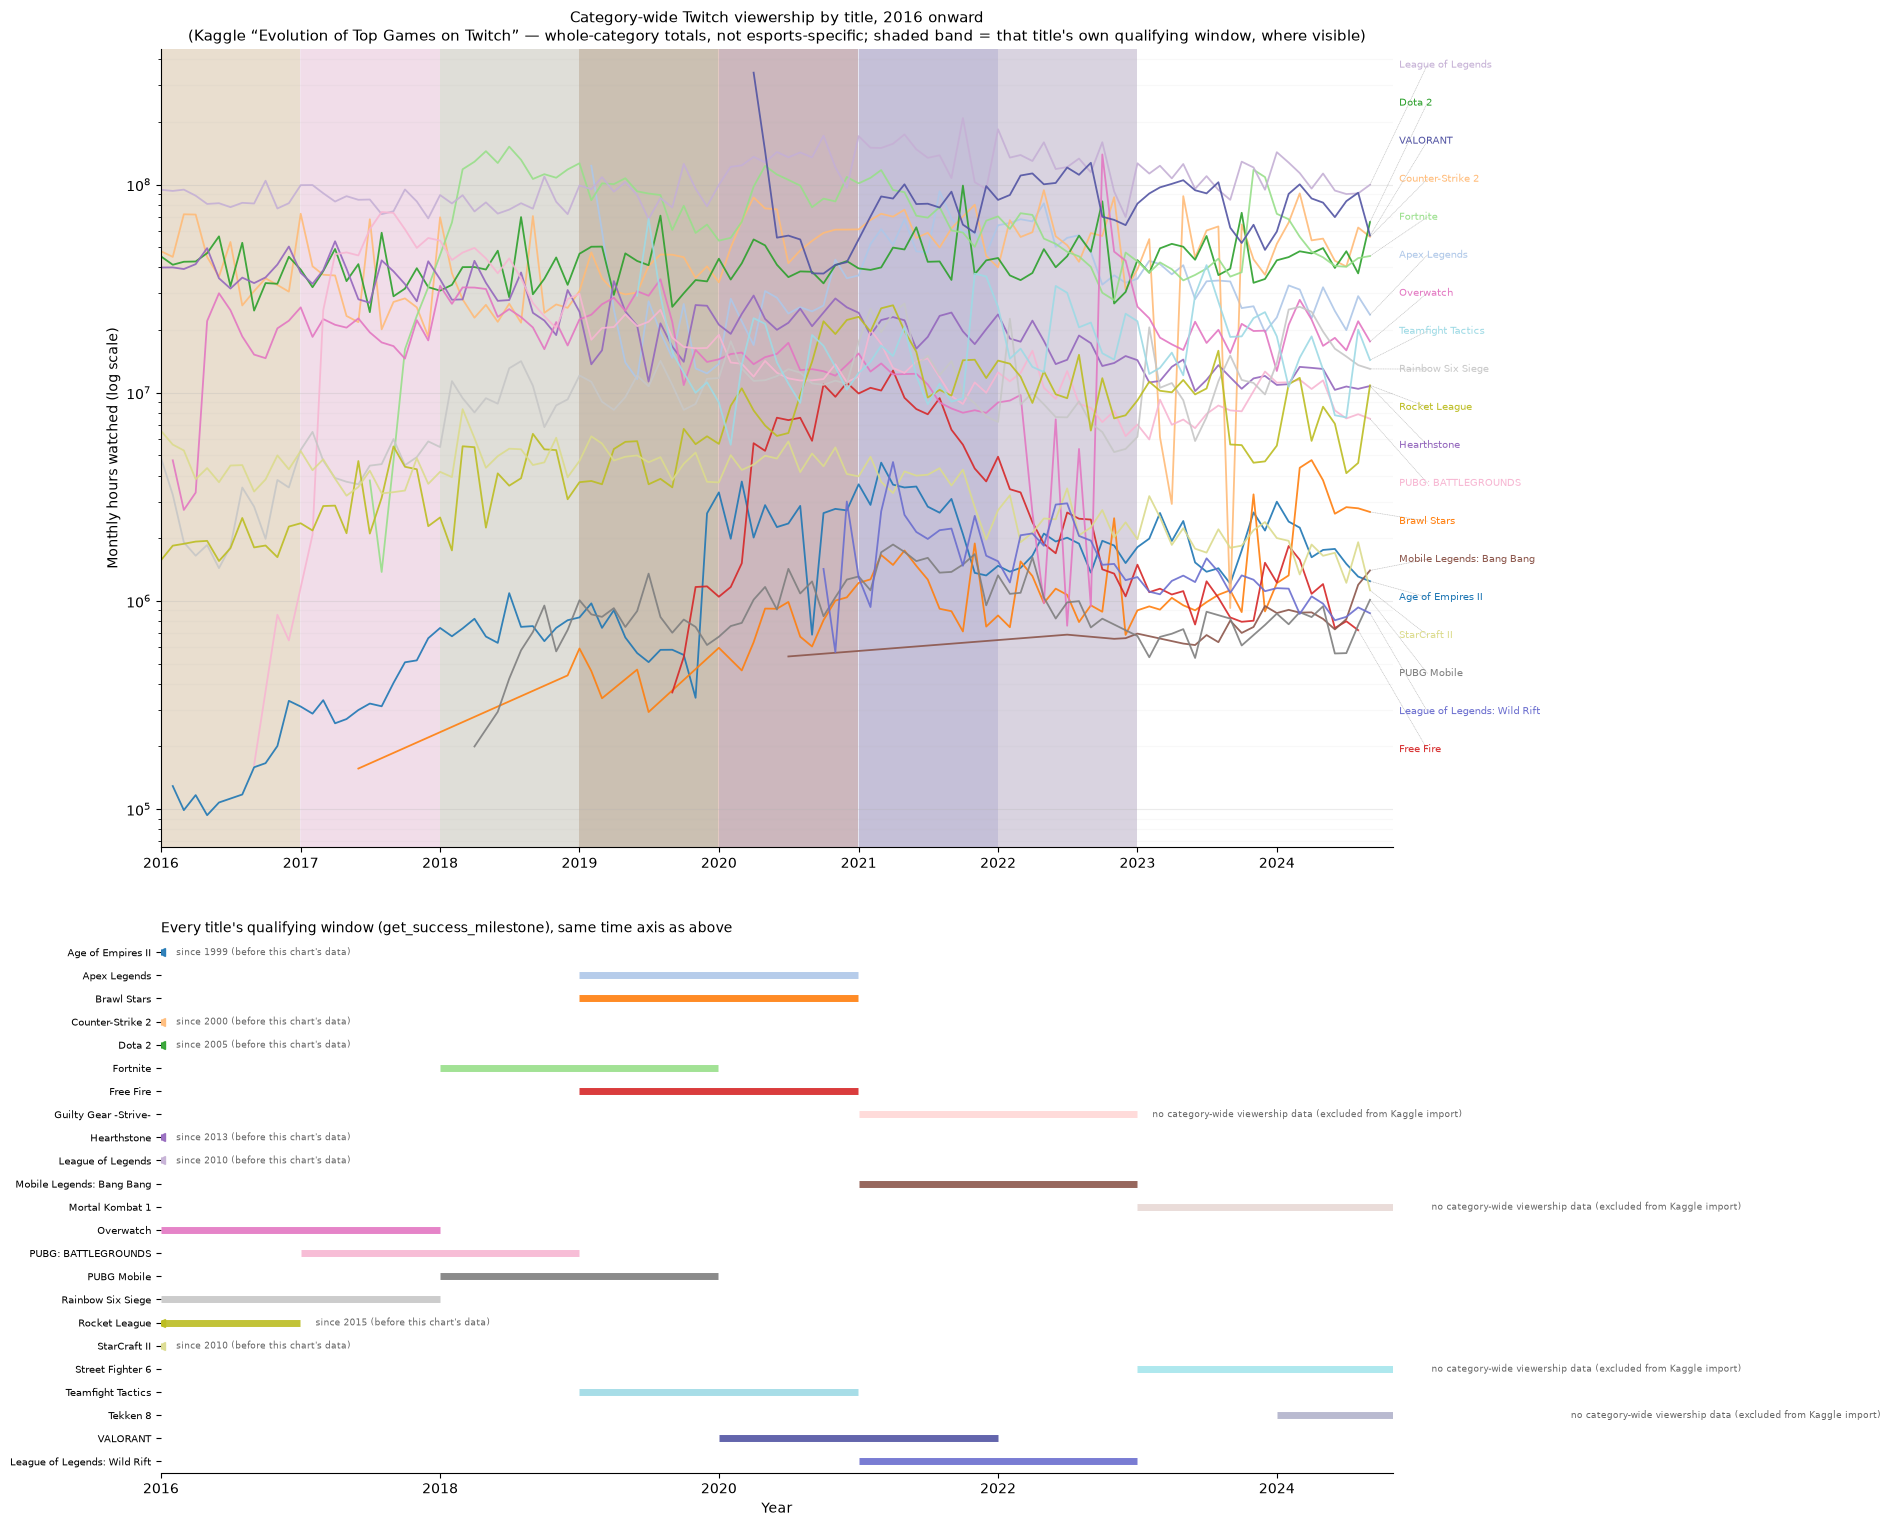

In [5]:
# Fixed, deterministic color assignment (alphabetical by title_id) — never
# re-derived from plot/sort order, so a title's color is stable across runs.
_cmap_colors = list(plt.get_cmap("tab20").colors) + list(plt.get_cmap("tab20b").colors)
color_by_title = {t: _cmap_colors[i % len(_cmap_colors)] for i, t in enumerate(title_ids)}

CHART_START = pd.Timestamp("2016-01-01")
chart_end = monthly_df["month"].max()
chart_xlim_end = chart_end + pd.Timedelta(days=900)  # wide runway so label connectors read as clearly separate from real data, not a continuation of it
visible_end = chart_end + pd.Timedelta(days=60)  # actual plotted x-range; the label runway beyond it is drawn (unclipped) but not part of the scanned chart area

fig, (ax_top, ax_strip) = plt.subplots(2, 1, figsize=(16, 16), height_ratios=[3, 2])
fig.subplots_adjust(left=0.06, right=0.83, top=0.94, bottom=0.05, hspace=0.14)

# --- Top panel: log-scale monthly hours watched, one line per title with data ---
ax_top.set_xlim(CHART_START, visible_end)
ax_top.set_yscale("log")
ylim = (max(1, monthly_df["hours_watched"].min() * 0.7), monthly_df["hours_watched"].max() * 1.3)
ax_top.set_ylim(*ylim)
log_ylim = (math.log10(ylim[0]), math.log10(ylim[1]))

end_points = []  # (title_id, month, value) for the most recent data point per title
for title_id in titles_with_data:
    sub = monthly_df[monthly_df["title_id"] == title_id].sort_values("month")
    color = color_by_title[title_id]
    ax_top.plot(sub["month"], sub["hours_watched"], color=color, linewidth=1.3, alpha=0.9)

    last = sub.iloc[-1]
    end_points.append((title_id, last["month"], last["hours_watched"]))

    # Shade the qualifying window directly on this title's line, only where
    # it actually overlaps the visible axis.
    ws, my = window_start_by_title[title_id], milestone_year_by_title[title_id]
    if ws is not None and my is not None:
        win_start = pd.Timestamp(f"{ws}-01-01")
        win_end = pd.Timestamp(f"{my}-12-31")
        if win_end >= CHART_START and win_start <= chart_end:
            ax_top.axvspan(max(win_start, CHART_START), min(win_end, chart_end), color=color, alpha=0.15, lw=0)

# De-collide end-of-line labels: sort by last value, greedily enforce a
# minimum vertical gap in axes-fraction space, then — if that greedy pass
# ran past the top of the axis (it will, whenever many titles' last values
# cluster in the same order of magnitude relative to the full axis range)
# — shift the WHOLE stack down by the overflow so labels stay inside
# [0, 1] without clamping several of them onto the same spot (confirmed in
# an earlier draft: clamping alone produced overlapping text at the top).
MIN_GAP = 1.0 / (len(end_points) + 2)
end_points.sort(key=lambda r: r[2])
fracs = []
prev = None
for title_id, month, value in end_points:
    frac = (math.log10(value) - log_ylim[0]) / (log_ylim[1] - log_ylim[0])
    if prev is not None and frac - prev < MIN_GAP:
        frac = prev + MIN_GAP
    prev = frac
    fracs.append(frac)

MAX_FRAC = 0.98
overflow = max(0.0, fracs[-1] - MAX_FRAC)
if overflow > 0:
    fracs = [f - overflow for f in fracs]
label_frac = [(*end_points[i], fracs[i]) for i in range(len(end_points))]

# Connectors are deliberately NOT colored like the series they point to —
# an earlier draft used each title's own color here, which made the
# connector read as a continuation of that title's real data (looked like
# an extreme spike at the right edge). Neutral, thin, and dotted instead,
# so a leader line can never be mistaken for measured data.
trans = blended_transform_factory(ax_top.transData, ax_top.transAxes)
label_x = chart_xlim_end - pd.Timedelta(days=750)
for title_id, month, value, frac in label_frac:
    color = color_by_title[title_id]
    ax_top.annotate(
        "", xy=(month, value), xycoords="data",
        xytext=(label_x, frac), textcoords=trans,
        arrowprops=dict(arrowstyle="-", color="0.6", lw=0.5, alpha=0.6, linestyle=(0, (1, 1.5)), shrinkA=0, shrinkB=0),
        clip_on=False,
    )
    ax_top.text(
        1.005, frac, display_name_by_id[title_id],
        transform=blended_transform_factory(ax_top.transAxes, ax_top.transAxes),
        color=color, fontsize=7.5, va="center", ha="left", clip_on=False,
    )

ax_top.set_ylabel("Monthly hours watched (log scale)")
ax_top.set_title(
    "Category-wide Twitch viewership by title, 2016 onward\n"
    "(Kaggle “Evolution of Top Games on Twitch” — whole-category totals, not esports-specific; "
    "shaded band = that title's own qualifying window, where visible)",
    fontsize=11,
)
ax_top.grid(True, which="major", axis="y", alpha=0.25)
ax_top.grid(True, which="minor", axis="y", alpha=0.08)
ax_top.spines[["top", "right"]].set_visible(False)

# --- Bottom panel: every title's qualifying window, same time axis ---
row_order = title_ids  # same fixed order as color assignment
ax_strip.set_xlim(ax_top.get_xlim())
ax_strip.set_ylim(-0.5, len(row_order) - 0.5)
ax_strip.set_yticks(range(len(row_order)))
ax_strip.set_yticklabels([display_name_by_id[t] for t in row_order], fontsize=7.5)
ax_strip.invert_yaxis()

for i, title_id in enumerate(row_order):
    color = color_by_title[title_id]
    ws, my = window_start_by_title[title_id], milestone_year_by_title[title_id]
    has_data = title_id in titles_with_data

    if ws is None or my is None:
        ax_strip.text(CHART_START, i, "  no milestone found in tournament data", va="center", fontsize=7, color="0.45")
        continue

    win_start = pd.Timestamp(f"{ws}-01-01")
    win_end = pd.Timestamp(f"{my}-12-31")
    visible_start = max(win_start, CHART_START)
    alpha = 0.9 if has_data else 0.35  # mute rows with no viewership line above
    ax_strip.plot([visible_start, win_end], [i, i], color=color, linewidth=5, solid_capstyle="butt", alpha=alpha)

    # Label position: ALWAYS clamped inside the visible axis, even when the
    # true win_end is itself pre-2016 (e.g. Age of Empires II, 1999-2000) —
    # an earlier draft placed this label at the true win_end with
    # clip_on=False, which for a pre-2016 window put it far outside the
    # axis; Jupyter's tight-bbox capture then expanded the whole canvas to
    # include that off-screen text, producing a huge blank margin. Every
    # unclipped artist on this figure must stay within the visible x-range
    # for that reason (win_end is always <= chart_end <= visible_end, so
    # no further clamping needed on that side).
    label_bits = []
    label_x2 = max(win_end + pd.Timedelta(days=40), CHART_START + pd.Timedelta(days=40))
    if win_start < CHART_START:
        ax_strip.plot(CHART_START, i, marker="<", color=color, markersize=6, alpha=alpha)
        label_bits.append(f"since {ws} (before this chart's data)")
    if not has_data:
        label_bits.append("no category-wide viewership data (excluded from Kaggle import)")
    if label_bits:
        ax_strip.text(label_x2, i, " · ".join(label_bits), va="center", fontsize=6.5, color="0.4", clip_on=False)

ax_strip.set_xlabel("Year")
ax_strip.set_title("Every title's qualifying window (get_success_milestone), same time axis as above", fontsize=10, loc="left")
ax_strip.spines[["top", "right", "left"]].set_visible(False)
ax_strip.xaxis.set_major_locator(mdates.YearLocator(2))
ax_strip.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.show()